# Q1: Baseline Characteristics Summary Report

## 1. Cohort Overview

The cohort shows a relatively **older population with normal-to-overweight BMI distribution**:

* **Age:** ~71–72 years on average across groups
* **BMI:** ~27–28 kg/m² across all comparisons
* No meaningful age or BMI differences were observed between **risk groups** (p > 0.7 for both)

Interpretation: The cohort is demographically homogeneous with respect to age and BMI, limiting confounding from these variables.

---

## 2. Baseline Characteristics by Risk Status (At Risk vs Not At Risk)

### Demographics

* **Ethnicity:** No statistically significant differences (p = 0.36)

  * Majority Caucasian (~50–60%)
  * Smaller representation of Asian, Black, Hispanic, and Other groups

---

### Cardio-metabolic Risk Factors

No significant differences in prevalence between risk groups:

* **Hypertension (HTN):** borderline trend (p = 0.056)

  * Higher prevalence in at-risk group (67.9% vs 53.3%)
* **Hyperlipidemia (HLD):** no difference (p = 1.00)
* **Type 2 Diabetes (DM2):** no difference (p = 0.70)
* **Smoking history:** trend toward higher smoking in at-risk group (p = 0.072)
* **Coronary artery disease (CAD):** no difference (p = 0.55)
* **Heart failure (CHF):** no difference (p = 1.00)
* **Arrhythmia / PAD / CVA:** all non-significant

Interpretation:
Cardiovascular comorbidities are **numerically higher in at-risk patients**, but not statistically significant in this dataset.

---

### Healthcare Access / Preventive Care

* **Primary care provider (PCP):** no difference (p = 0.26)
* **Cardiology prior care:** no difference (p = 0.13)

---

### Preventive Counseling & Testing

* **Diet counseling:** not significant (p = 0.20)
* **Exercise counseling:** **significant difference (p = 0.036)**

  * More counseling in at-risk group
* **Echocardiogram ordered:** **significant difference (p = 0.016)**

  * More frequent in at-risk group
* **ECG done:** no difference (p = 0.78)

Interpretation:
At-risk patients receive **more cardiometabolic evaluation and counseling**, suggesting appropriate clinical escalation.

---

## 3. ADT Agent Group Differences

### Key Finding

Most baseline variables are balanced across ADT agents, with a few exceptions:

#### Significant differences:

* **Coronary artery disease (CAD):** p = 0.011
* **Exercise counseling:** p = 0.036
* **Echocardiogram ordering:** p = 0.016

#### Non-significant:

* Age (p = 0.18)
* BMI (p = 0.90)
* Most comorbidities (HTN, DM, CHF, etc.)
* Ethnicity (p = 0.66)

Interpretation:
ADT agents are **largely comparable at baseline**, though CAD prevalence and preventive care practices differ modestly.

---

## 4. Specific NHT Therapy Group Differences

### Significant findings:

* **Age:** p = 0.0004 (strong difference)

  * Younger patients on Abiraterone (~68.7 yrs)
  * Older patients on Darolutamide (~74.2 yrs)

* **Arrhythmia:** p = 0.0498

  * Uneven distribution across agents

### Non-significant:

* BMI (p = 0.39)
* Ethnicity (p = 0.35)
* HTN, HLD, DM, smoking
* CAD, CHF, PAD, CVA
* Preventive care variables mostly non-significant

Interpretation:
Treatment allocation differs modestly by **age and arrhythmia history**, but is otherwise balanced.

---

## 5. Key Clinical Insights

### Overall patterns:

* Cohort is **clinically homogeneous overall**
* Most cardiometabolic risk factors are evenly distributed
* Preventive care (echo, counseling) shows **selective escalation in higher-risk patients**
* Treatment assignment (ADT/NHT) is mostly balanced, with **age-driven prescribing patterns**





In [1]:
import os
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

In [3]:
BASE_FILE = os.path.join("..", "..", "data", "processed", "cardio_onc_prostate_06_broad_clean.csv")

df = pd.read_csv(BASE_FILE)

print(df.shape)
df.head()

(239, 60)


,unique_patient_id,ethnicity,nht_auth_date,nht_start_date,bmi,specific_nht_used,age,adt_start_date,adt_agent,hx_smoking,...,bp_meds_post_binary,lipid_meds_post_binary,dm_meds_post_binary,at_risk,lifestyle_counseling,dm_severity,ethnicity_enc,specific_nht_used_enc,adt_agent_enc,prescribing_provider_enc
0,1.0,NaN,2022-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,27.0
1,2.0,NaN,2022-01-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,27.0
2,3.0,Caucasian,2022-01-12,2022-02-01,25.99,Darolutamide,73.0,2018-01-26,Lupron,1.0,...,0.0,0.0,0.0,0.0,0,0.0,2.0,2.0,2.0,27.0
3,4.0,Asian,2022-01-14,2022-02-14,22.55,Apalutamide,93.0,2021-12-01,Bicalutamide,0.0,...,0.0,0.0,0.0,0.0,0,0.0,0.0,1.0,0.0,42.0
4,5.0,NaN,2022-01-19,NaN,NaN,Abiraterone,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,NaN,NaN,0.0,NaN,7.0


In [4]:
# Outcome
target = "at_risk"

# Demographics
demographics = ["age", "ethnicity", "bmi"]

# Risk factors
risk_factors = [
    "hx_htn", "hx_hld", "hx_dm2", "hx_smoking",
    "hx_cad", "hx_chf", "hx_arrhythmia", "hx_pad", "hx_cva"
]

# Care patterns
care_patterns = [
    "has_pcp", "cards_prior",
    "diet_counseling", "exercise_counseling",
    "echo_ordered", "ecg_done"
]

all_features = demographics + risk_factors + care_patterns

In [5]:
def summarize_continuous(df, col, target):
    group0 = df[df[target] == 0][col].dropna()
    group1 = df[df[target] == 1][col].dropna()

    # Summary stats
    summary = {
        "Overall": f"{df[col].mean():.2f} ± {df[col].std():.2f}",
        "Not At Risk": f"{group0.mean():.2f} ± {group0.std():.2f}",
        "At Risk": f"{group1.mean():.2f} ± {group1.std():.2f}",
    }

    # Normality check (quick heuristic)
    if len(group0) > 20 and len(group1) > 20:
        p_norm = stats.shapiro(df[col].dropna().sample(min(500, len(df[col].dropna()))))[1]
    else:
        p_norm = 0

    # Choose test
    if p_norm > 0.05:
        stat, p = stats.ttest_ind(group0, group1, equal_var = False)
        test = "t-test"
    else:
        stat, p = stats.mannwhitneyu(group0, group1, alternative = "two-sided")
        test = "Mann-Whitney"

    summary["p-value"] = f"{p:.4f}"
    summary["Test"] = test

    return summary

In [6]:
def summarize_categorical(df, col, target):
    ct = pd.crosstab(df[col], df[target])

    # Percentages
    pct = ct.div(ct.sum(axis = 0), axis = 1) * 100

    # Chi-square
    try:
        chi2, p, _, _ = stats.chi2_contingency(ct)
    except:
        p = np.nan

    rows = []
    for category in ct.index:
        row = {
            "Variable": f"{col} = {category}",
            "Overall": f"{ct.loc[category].sum()}",
            "Not At Risk": f"{ct.loc[category, 0]} ({pct.loc[category, 0]:.1f}%)" if 0 in ct.columns else "0",
            "At Risk": f"{ct.loc[category, 1]} ({pct.loc[category, 1]:.1f}%)" if 1 in ct.columns else "0",
            "p-value": f"{p:.4f}"
        }
        rows.append(row)

    return rows

In [7]:
table1_rows = []

# Continuous variables
for col in ["age", "bmi"]:
    summary = summarize_continuous(df, col, target)
    row = {
        "Variable": col,
        "Overall": summary["Overall"],
        "Not At Risk": summary["Not At Risk"],
        "At Risk": summary["At Risk"],
        "p-value": summary["p-value"]
    }
    table1_rows.append(row)

# Categorical variables
categorical_vars = [
    "ethnicity", "hx_htn", "hx_hld", "hx_dm2", "hx_smoking",
    "hx_cad", "hx_chf", "hx_arrhythmia", "hx_pad", "hx_cva",
    "has_pcp", "cards_prior",
    "diet_counseling", "exercise_counseling",
    "echo_ordered", "ecg_done"
]

for col in categorical_vars:
    rows = summarize_categorical(df, col, target)
    table1_rows.extend(rows)

table1 = pd.DataFrame(table1_rows)

print(table1.head(20))

                 Variable       Overall   Not At Risk       At Risk p-value
0                     age  71.60 ± 8.91  71.77 ± 9.38  71.41 ± 8.46  0.7733
1                     bmi  27.66 ± 5.13  27.80 ± 5.22  27.52 ± 5.11  0.8451
2       ethnicity = Asian            27    15 (12.5%)    12 (15.2%)  0.3554
3       ethnicity = Black            17      8 (6.7%)     9 (11.4%)  0.3554
4   ethnicity = Caucasian           110    71 (59.2%)    39 (49.4%)  0.3554
5    ethnicity = Hispanic            22    15 (12.5%)      7 (8.9%)  0.3554
6       ethnicity = Other            23     11 (9.2%)    12 (15.2%)  0.3554
7            hx_htn = 0.0            82    57 (46.7%)    25 (32.1%)  0.0561
8            hx_htn = 1.0           118    65 (53.3%)    53 (67.9%)  0.0561
9            hx_hld = 0.0            96    59 (47.6%)    37 (46.8%)  1.0000
10           hx_hld = 1.0           107    65 (52.4%)    42 (53.2%)  1.0000
11           hx_dm2 = 0.0           141    88 (71.5%)    53 (67.9%)  0.7004
12          

In [9]:
import os

OUT_DIR = os.path.join("..", "results", "01")
os.makedirs(OUT_DIR, exist_ok=True)

OUT_FILE = os.path.join(OUT_DIR, "table1_baseline.csv")

table1.to_csv(OUT_FILE, index=False)

print(f"Saved Table 1 to: {OUT_FILE}")

Saved Table 1 to: ../results/01/table1_baseline.csv


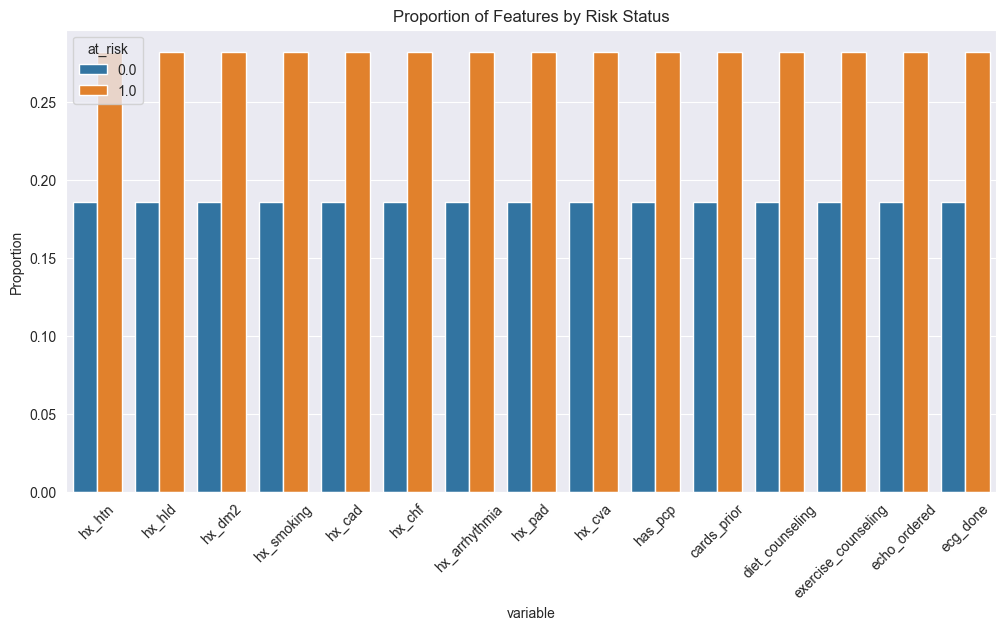

In [10]:
binary_cols = risk_factors + [
    "has_pcp", "cards_prior",
    "diet_counseling", "exercise_counseling",
    "echo_ordered", "ecg_done"
]

plot_df = []

for col in binary_cols:
    temp = df.groupby(target)[col].mean().reset_index()
    temp["variable"] = col
    plot_df.append(temp)

plot_df = pd.concat(plot_df)

plt.figure(figsize = (12, 6))
sns.barplot(data = plot_df, x = "variable", y = col, hue = target)
plt.xticks(rotation = 45)
plt.title("Proportion of Features by Risk Status")
plt.ylabel("Proportion")
plt.show()

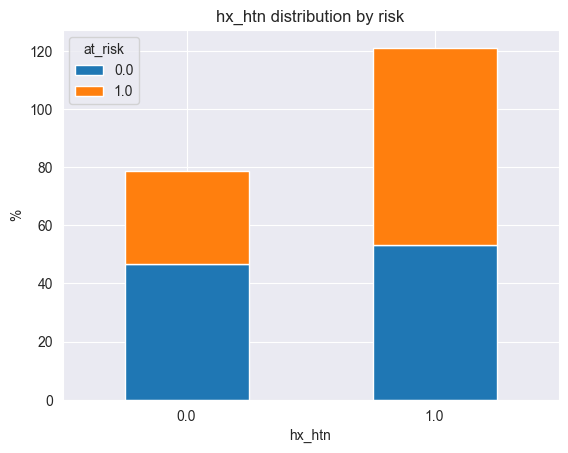

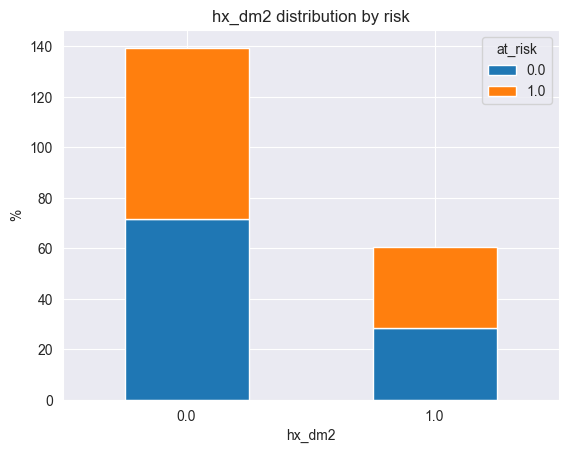

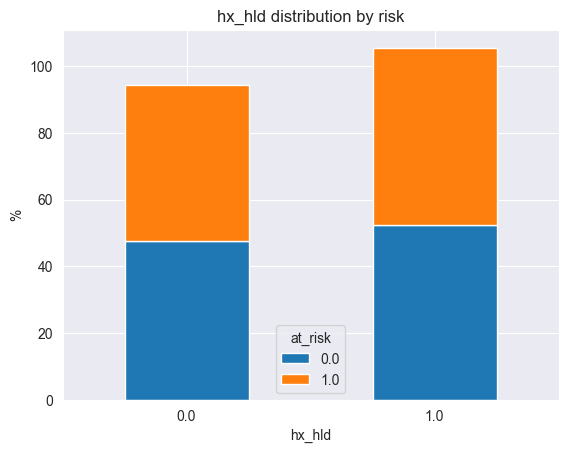

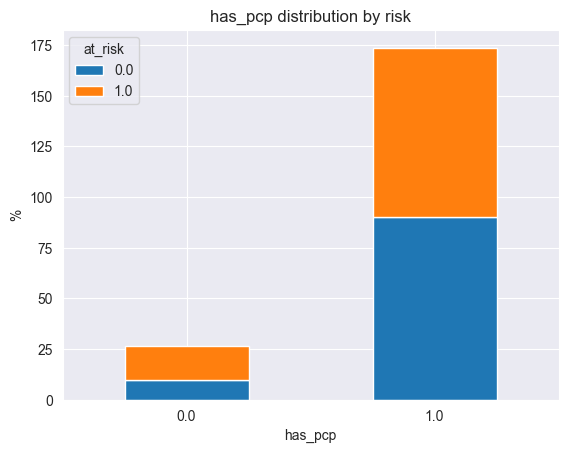

In [11]:
def stacked_plot(df, col, target):
    ct = pd.crosstab(df[col], df[target], normalize = "columns") * 100
    ct.plot(kind = "bar", stacked = True)
    plt.title(f"{col} distribution by risk")
    plt.ylabel("%")
    plt.xticks(rotation = 0)
    plt.show()


for col in ["hx_htn", "hx_dm2", "hx_hld", "has_pcp"]:
    stacked_plot(df, col, target)

In [12]:
table1["p-value"] = table1["p-value"].replace("nan", "")
table1.fillna("", inplace = True)

table1.head(30)

,Variable,Overall,Not At Risk,At Risk,p-value
0,age,71.60 ± 8.91,71.77 ± 9.38,71.41 ± 8.46,0.7733
1,bmi,27.66 ± 5.13,27.80 ± 5.22,27.52 ± 5.11,0.8451
2,ethnicity = Asian,27,15 (12.5%),12 (15.2%),0.3554
3,ethnicity = Black,17,8 (6.7%),9 (11.4%),0.3554
4,ethnicity = Caucasian,110,71 (59.2%),39 (49.4%),0.3554
5,ethnicity = Hispanic,22,15 (12.5%),7 (8.9%),0.3554
6,ethnicity = Other,23,11 (9.2%),12 (15.2%),0.3554
7,hx_htn = 0.0,82,57 (46.7%),25 (32.1%),0.0561
8,hx_htn = 1.0,118,65 (53.3%),53 (67.9%),0.0561
9,hx_hld = 0.0,96,59 (47.6%),37 (46.8%),1.0000


In [13]:
group_var = "adt_agent"

# Optional: collapse rare categories to avoid unstable stats
min_n = 5
counts = df[group_var].value_counts()

valid_groups = counts[counts >= min_n].index
df_adt = df[df[group_var].isin(valid_groups)].copy()

print(df_adt[group_var].value_counts())

adt_agent
Orgovyx         80
Lupron          55
Bicalutamide    27
Firmagon        18
Name: count, dtype: int64


In [14]:
def summarize_continuous_by_group(df, col, group_var):
    groups = [g[col].dropna() for _, g in df.groupby(group_var)]

    # Summary table
    summary = df.groupby(group_var)[col].agg(["mean", "std", "median", "count"])

    # Normality (quick check)
    p_norm = stats.shapiro(df[col].dropna().sample(min(500, len(df[col].dropna()))))[1]

    if p_norm > 0.05:
        stat, p = stats.f_oneway(*groups)
        test = "ANOVA"
    else:
        stat, p = stats.kruskal(*groups)
        test = "Kruskal-Wallis"

    return summary, p, test

In [15]:
def summarize_categorical_by_group(df, col, group_var):
    ct = pd.crosstab(df[col], df[group_var])

    try:
        chi2, p, _, _ = stats.chi2_contingency(ct)
    except:
        p = np.nan

    return ct, p

In [16]:
adt_results = []

# Continuous
for col in ["age", "bmi"]:
    summary, p, test = summarize_continuous_by_group(df_adt, col, group_var)

    adt_results.append({
        "Variable": col,
        "Test": test,
        "p-value": p
    })

    print(f"\n{col} ({test}) p={p:.4f}")
    print(summary)


# Categorical
for col in categorical_vars:
    ct, p = summarize_categorical_by_group(df_adt, col, group_var)

    adt_results.append({
        "Variable": col,
        "Test": "Chi-square",
        "p-value": p
    })

    print(f"\n{col} (Chi-square) p={p:.4f}")
    print(ct)


age (ANOVA) p=0.1823
                   mean       std  median  count
adt_agent                                       
Bicalutamide  72.222222  8.464102    73.0     27
Firmagon      70.444444  8.853196    69.5     18
Lupron        73.109091  9.132102    74.0     55
Orgovyx       69.797468  9.009083    70.0     79

bmi (Kruskal-Wallis) p=0.8961
                   mean       std  median  count
adt_agent                                       
Bicalutamide  28.718889  7.945258   27.25     27
Firmagon      27.120000  4.014953   26.90     18
Lupron        27.834815  5.233023   27.90     54
Orgovyx       27.710506  4.526987   28.07     79

ethnicity (Chi-square) p=0.6597
adt_agent  Bicalutamide  Firmagon  Lupron  Orgovyx
ethnicity                                         
Asian                 5         4       8        8
Black                 4         2       3        6
Caucasian            13        11      31       44
Hispanic              2         1       7        8
Other               

In [17]:
adt_table = pd.DataFrame(adt_results)

OUT_FILE = os.path.join(OUT_DIR, "adt_group_comparisons.csv")
adt_table.to_csv(OUT_FILE, index=False)

print(f"Saved ADT comparison results to: {OUT_FILE}")

Saved ADT comparison results to: ../results/01/adt_group_comparisons.csv


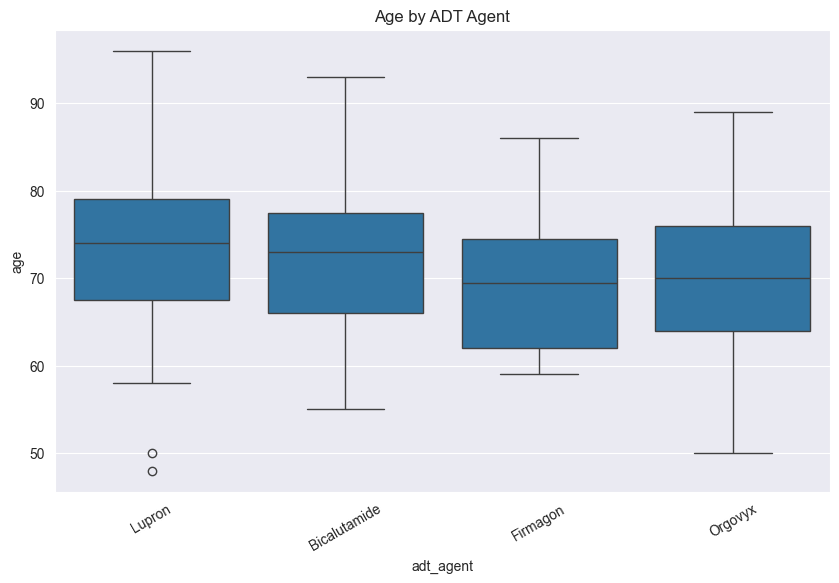

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_adt, x="adt_agent", y="age")
plt.xticks(rotation=30)
plt.title("Age by ADT Agent")
plt.show()

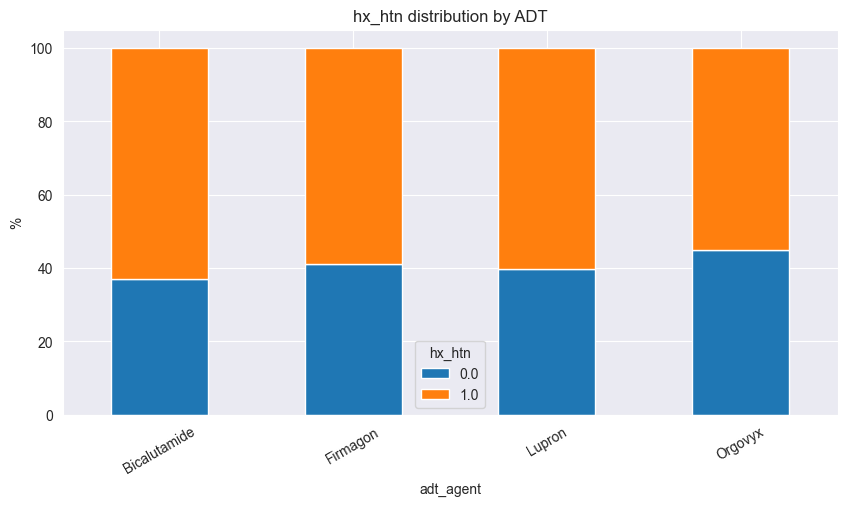

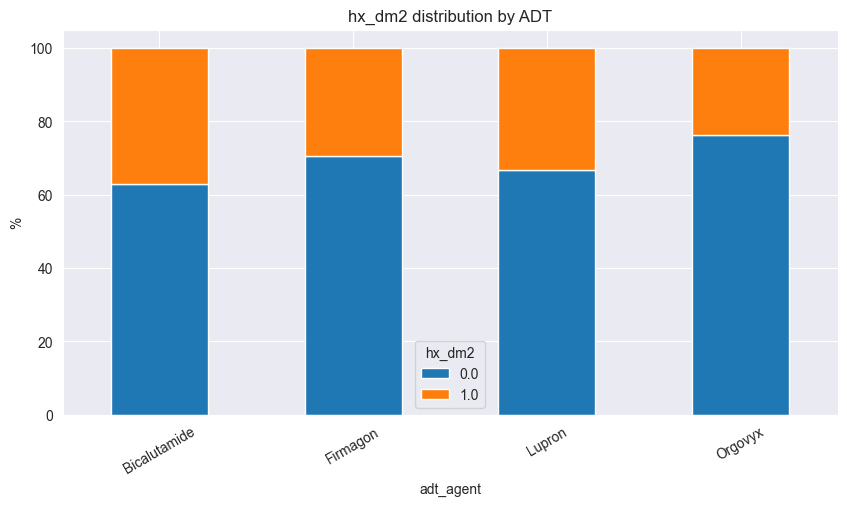

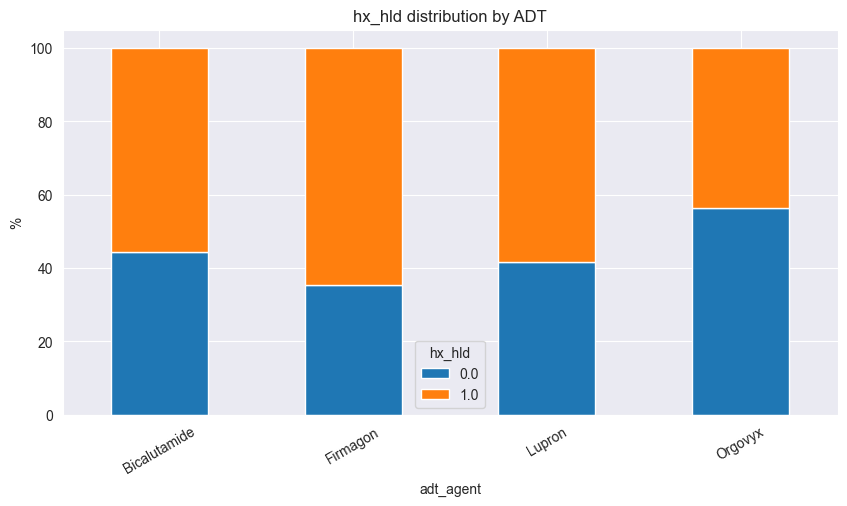

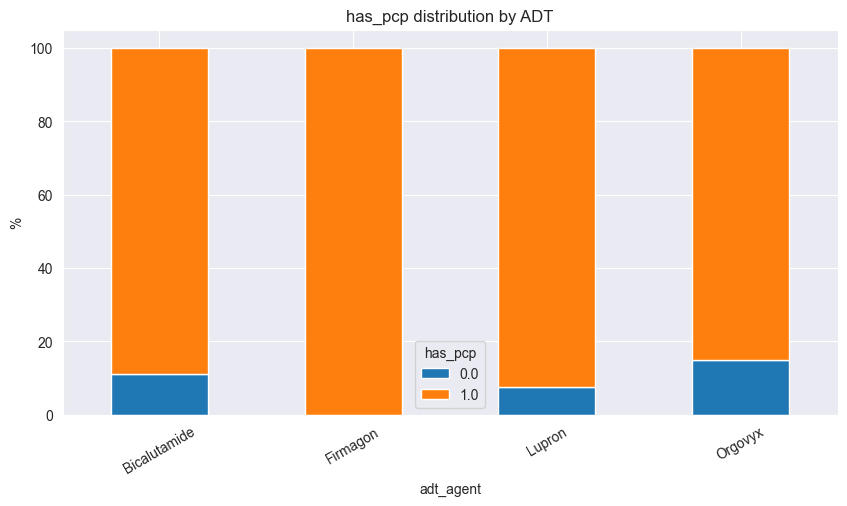

In [19]:
for col in ["hx_htn", "hx_dm2", "hx_hld", "has_pcp"]:
    ct = pd.crosstab(df_adt[col], df_adt[group_var], normalize="columns") * 100
    ct.T.plot(kind="bar", stacked=True, figsize=(10, 5))
    plt.title(f"{col} distribution by ADT")
    plt.ylabel("%")
    plt.xticks(rotation=30)
    plt.show()

In [26]:
group_var = "specific_nht_used"

print(f"\n=== Baseline differences across {group_var} ===\n")

# Continuous variables
for col in ["age", "bmi"]:
    groups = [g[col].dropna() for _, g in df.groupby(group_var)]

    # Normality check (same logic)
    p_norm = stats.shapiro(df[col].dropna().sample(min(500, len(df[col].dropna()))))[1]

    if p_norm > 0.05:
        stat, p = stats.f_oneway(*groups)
        test = "ANOVA"
    else:
        stat, p = stats.kruskal(*groups)
        test = "Kruskal-Wallis"

    print(f"\n{col} ({test}) p={p:.4f}")
    print(df.groupby(group_var)[col].agg(["mean", "std", "median", "count"]))

# Categorical variables
categorical_vars = [
    "ethnicity", "hx_htn", "hx_hld", "hx_dm2", "hx_smoking",
    "hx_cad", "hx_chf", "hx_arrhythmia", "hx_pad", "hx_cva",
    "has_pcp", "cards_prior",
    "diet_counseling", "exercise_counseling",
    "echo_ordered", "ecg_done"
]

for col in categorical_vars:
    ct = pd.crosstab(df[col], df[group_var])

    try:
        chi2, p, _, _ = stats.chi2_contingency(ct)
    except:
        p = np.nan

    print(f"\n{col} (Chi-square) p={p:.4f}")
    print(ct)


=== Baseline differences across specific_nht_used ===


age (ANOVA) p=0.0004
                        mean       std  median  count
specific_nht_used                                    
Abiraterone        68.685393  9.024708    69.0     89
Apalutamide        72.071429  8.713070    73.5     14
Darolutamide       74.204819  8.412765    75.0     83
Enzalutamide       73.333333  7.164728    71.0     21

bmi (Kruskal-Wallis) p=0.3917
                        mean       std  median  count
specific_nht_used                                    
Abiraterone        28.305333  5.882066  28.180     90
Apalutamide        27.222857  4.710082  26.565     14
Darolutamide       26.866024  4.462692  26.520     83
Enzalutamide       28.398000  4.123491  28.195     20

ethnicity (Chi-square) p=0.3540
specific_nht_used  Abiraterone  Apalutamide  Darolutamide  Enzalutamide
ethnicity                                                              
Asian                       14            3             9         